In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import cv2
import os
import glob
import torchvision
import torch
import numpy as np
import pandas as pd
import albumentations as A
import seaborn as sns
import shutil as sh

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from PIL import Image
from torchvision import models
from torchvision import transforms
from tqdm.notebook import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from albumentations.pytorch.transforms import ToTensorV2
from sklearn.model_selection import train_test_split
from xml.etree import ElementTree as ET
from matplotlib.pyplot import *

%matplotlib inline

In [ ]:
from google.colab import drive


In [ ]:
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
#  Data Preprocessing

In [ ]:
print(f'images_len {len(os.listdir("/content/drive/MyDrive/archive (22)/images"))}')
print(f'annotations_len {len(os.listdir("/content/drive/MyDrive/archive (22)/annotations"))}')

images_len 853
annotations_len 669


In [ ]:
# Path to the folder with the dataset
DATASET_PATH = "/content/drive/MyDrive/archive (22)"
# Path to the folder with the annotations
ANNOTATIONS_PATH = os.path.join(DATASET_PATH, "annotations")
# Path to the folder with the dataset
IMAGES_PATH = os.path.join(DATASET_PATH, "images")

print(ANNOTATIONS_PATH)
print(IMAGES_PATH)

/content/drive/MyDrive/archive (22)/annotations
/content/drive/MyDrive/archive (22)/images


Image shape: (225, 400, 4)
Image shape: (400, 301, 4)
Image shape: (366, 512, 3)
Image shape: (400, 301, 4)
Image shape: (225, 400, 4)


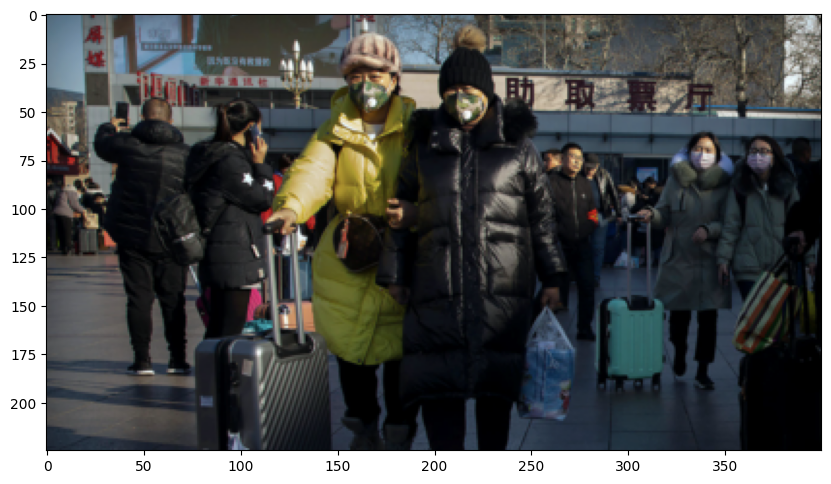

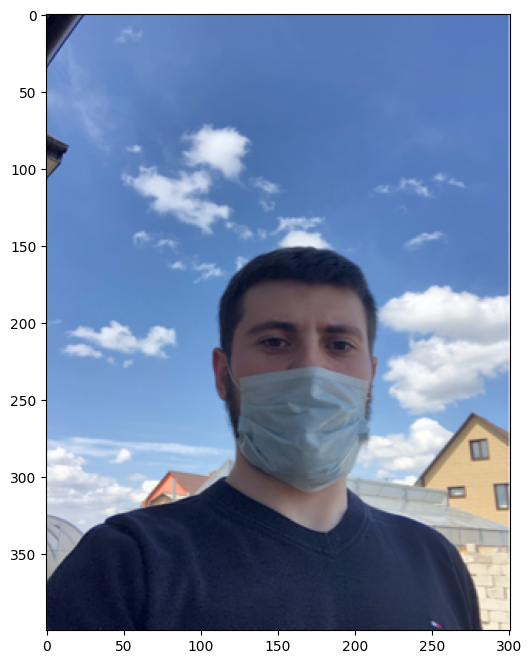

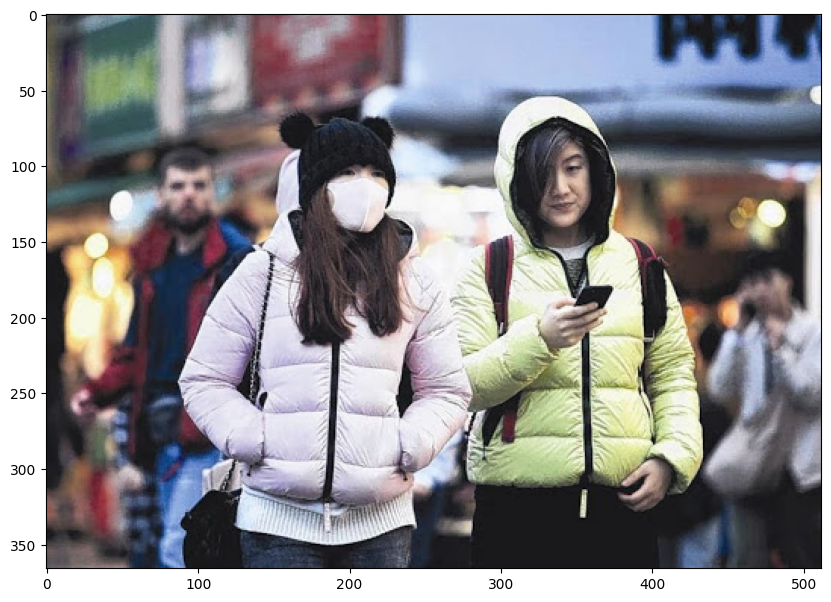

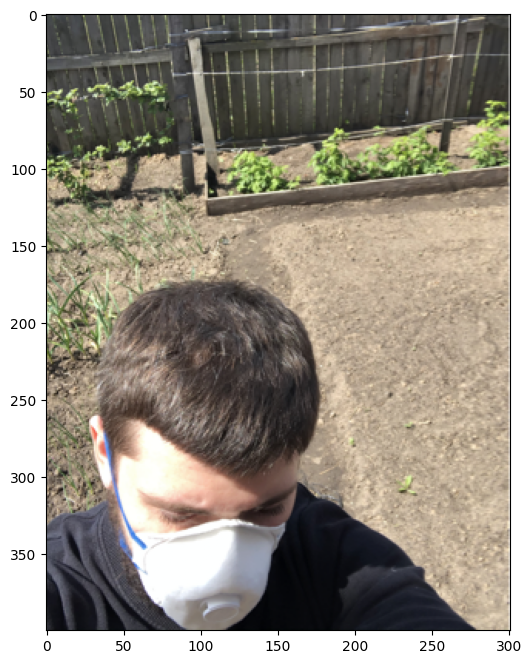

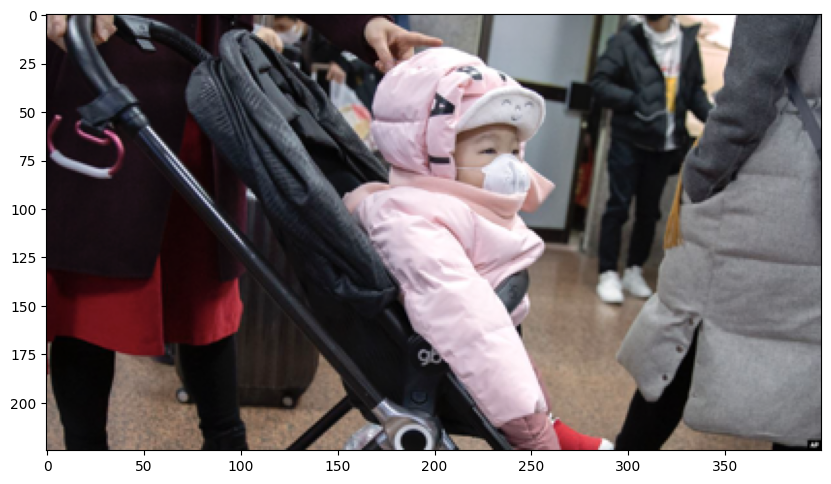

In [ ]:
filenames = list(os.listdir("/content/drive/MyDrive/archive (22)/images"))
for image_filename in filenames[:5]:
    image_path = os.path.join(IMAGES_PATH, image_filename)
# Reading the image
    img = plt.imread(image_path)
    # Displaying the image size
    print('Image shape: {}'.format(img.shape))
# Create a figure and coordinate plane
    fig, ax = plt.subplots(figsize=(10, 8))
# Displaying the image on the screen
    ax.imshow(img);

Image shape: (366, 512, 3)

<annotation>
    <folder>images</folder>
    <filename>maksssksksss0.png</filename>
    <size>
        <width>512</width>
        <height>366</height>
        <depth>3</depth>
    </size>
    <segmented>0</segmented>
    <object>
        <name>without_mask</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>
        <occluded>0</occluded>
        <difficult>0</difficult>
        <bndbox>
            <xmin>79</xmin>
            <ymin>105</ymin>
            <xmax>109</xmax>
            <ymax>142</ymax>
        </bndbox>
    </object>
    <object>
        <name>with_mask</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>
        <occluded>0</occluded>
        <difficult>0</difficult>
        <bndbox>
            <xmin>185</xmin>
            <ymin>100</ymin>
            <xmax>226</xmax>
            <ymax>144</ymax>
        </bndbox>
    </object>
    <object>
        <name>without_mask</name>
        <pose>Unspecified</p

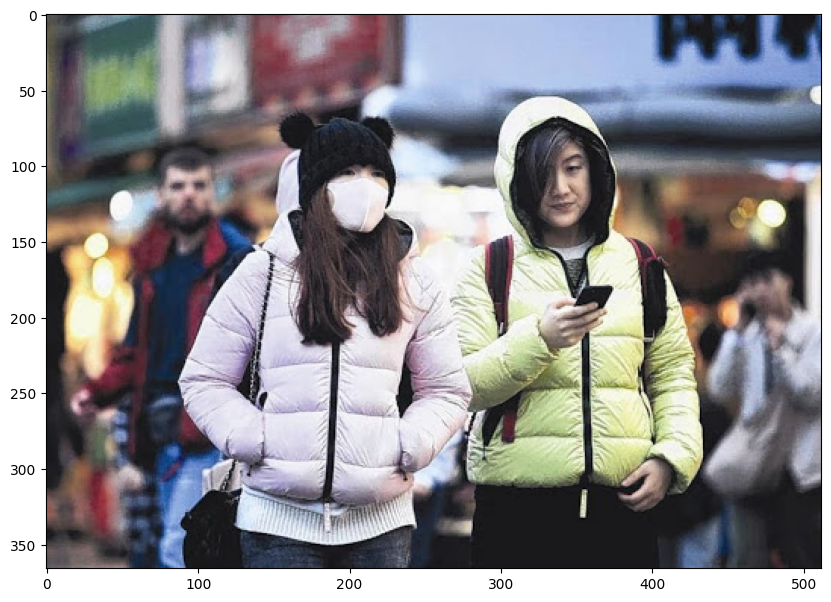

In [ ]:
# Making the path to the file
image_filename = 'maksssksksss0.png'
image_path = os.path.join(IMAGES_PATH, image_filename)
# Reading the image
img = plt.imread(image_path)
# Create a figure and coordinate plane
fig, ax = plt.subplots(figsize=(10, 8))
# Displaying the image
ax.imshow(img);
# Displaying the image size
print('Image shape: {}'.format(img.shape))

# Let's read one of the annotation files and look at its contents
with open(os.path.join(ANNOTATIONS_PATH, 'maksssksksss0.xml')) as f:
    print(f.read())

In [ ]:
# We create a dataframe from the coordinates of frames and classes
# Dictionary for dataframe features
df_dict = {
    "filename":[], "xmin":[], "ymin":[],
    "xmax":[],"ymax":[], "name":[],
    "width":[], "height":[],
}

# Create a loop through all annotations
for annotation in glob.glob(ANNOTATIONS_PATH+"/*.xml"):
    # Read the XML file with annotation
    tree = ET.parse(annotation)
    # Find the tag corresponding to the file name
    filename = tree.find('filename').text
    # Create a loop through all elements of the XML file
    for elem in tree.iter():
        # We extract information about the image size from the annotation - width and height
        if 'size' in elem.tag:
            for attr in list(elem):
                if 'width' in attr.tag:
                    width = int(round(float(attr.text)))
                if 'height' in attr.tag:
                    height = int(round(float(attr.text)))
        # Retrieving information about the image - class name and information about bounding box coordinates
        if 'object' in elem.tag:
            for attr in list(elem):
                if 'name' in attr.tag:
                    name = attr.text
                    df_dict['name'] += [name]
                    df_dict['width'] += [width]
                    df_dict['height'] += [height]
                    df_dict['filename'] += [filename]

                if 'bndbox' in attr.tag:
                    for dim in list(attr):
                        if 'xmin' in dim.tag:
                            xmin = int(round(float(dim.text)))
                            df_dict['xmin'] += [xmin]
                        if 'ymin' in dim.tag:
                            ymin = int(round(float(dim.text)))
                            df_dict['ymin'] += [ymin]
                        if 'xmax' in dim.tag:
                            xmax = int(round(float(dim.text)))
                            df_dict['xmax'] += [xmax]
                        if 'ymax' in dim.tag:
                            ymax = int(round(float(dim.text)))
                            df_dict['ymax'] += [ymax]

df = pd.DataFrame(df_dict)
display(df.head())
print(df.shape)






,filename,xmin,ymin,xmax,ymax,name,width,height
0,maksssksksss624.png,95,195,193,338,without_mask,301,400
1,maksssksksss622.png,138,66,171,99,with_mask,400,300
2,maksssksksss622.png,267,59,299,86,with_mask,400,300
3,maksssksksss622.png,322,76,342,100,with_mask,400,300
4,maksssksksss622.png,352,62,380,94,with_mask,400,300


(3371, 8)


In [ ]:
df.isnull().sum()

filename    0
xmin        0
ymin        0
xmax        0
ymax        0
name        0
width       0
height      0
dtype: int64

In [ ]:
print(df['name'].dtype)
print(df['name'].value_counts())


object
name
with_mask                2624
without_mask              646
mask_weared_incorrect     101
Name: count, dtype: int64


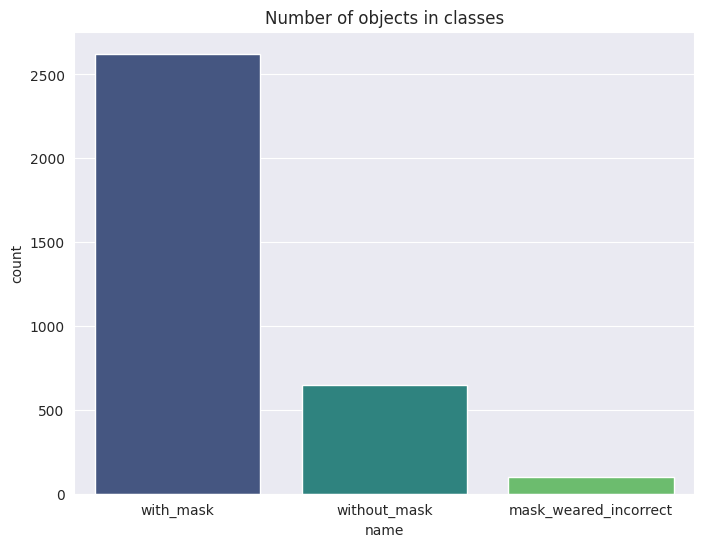

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is your DataFrame

# Group by 'name' and count occurrences
name_counts = df['name'].value_counts().reset_index(name='count')

# Create the bar plot
sns.barplot(data=name_counts, x='name', y='count', palette='viridis')
plt.title('Number of objects in classes')
plt.show()




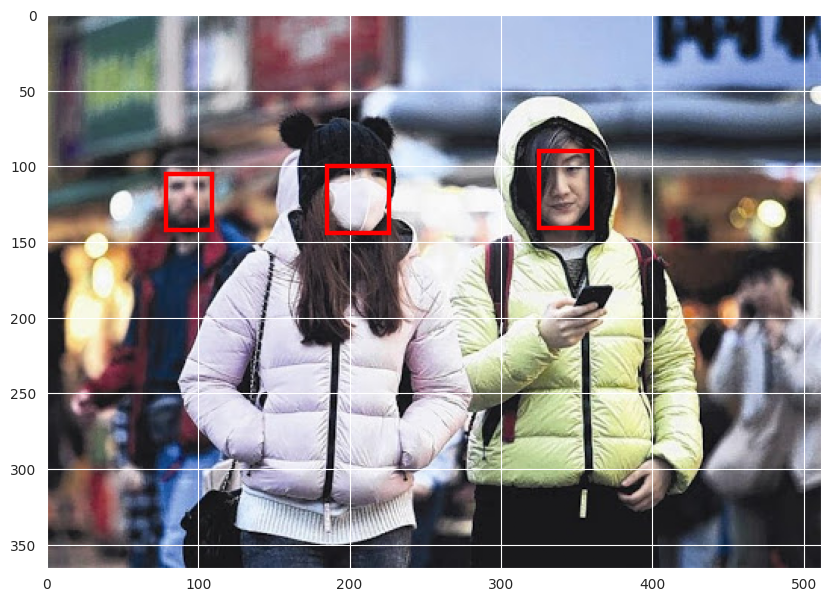

In [ ]:
# The function displays an image with a frame
def plot_bounding_box(image_folder, image_filename, df=df):
    # Create the full path to the image
    image_path = os.path.join(image_folder, image_filename)
    # Reading the image
    img = plt.imread(image_path)
    # Create a figure and coordinate plane
    fig, ax = plt.subplots(figsize=(10, 8))
    # Displaying the image on the screen
    ax.imshow(img);

    # Finding the image index in the DataFrame
    image_idx = df[df['filename'] == image_filename].index

    # Find the coordinates of the lower left point
    x_min = df.loc[image_idx, 'xmin'].values
    y_min = df.loc[image_idx, 'ymin'].values
    # Finding the width and height of the frame
    box_width = (df.loc[image_idx, 'xmax'] - df.loc[image_idx, 'xmin']).values
    box_height = (df.loc[image_idx, 'ymax'] - df.loc[image_idx, 'ymin']).values
    # Since there can be several bounding rectangles, we create a loop through all
    for i in range(len(image_idx)):
        # Building a rectangle
        rect = patches.Rectangle(
            (x_min[i], y_min[i]), # coordinates of the reference point
            box_width[i], # rectangle width
            box_height[i], # rectangle height
            linewidth=3, # line width
            edgecolor='r', # line color
            facecolor='none' # fill (none - absent)
        )
        # Overlay a rectangle on top of the image
        ax.add_patch(rect);

plot_bounding_box(image_folder=IMAGES_PATH, image_filename='maksssksksss0.png', df=df)

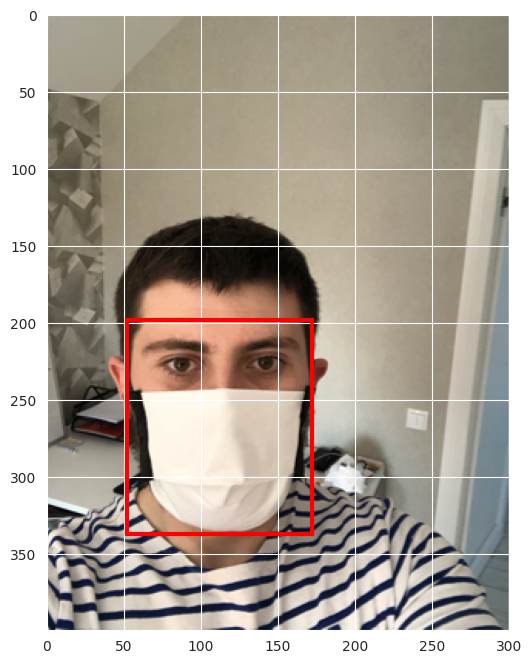

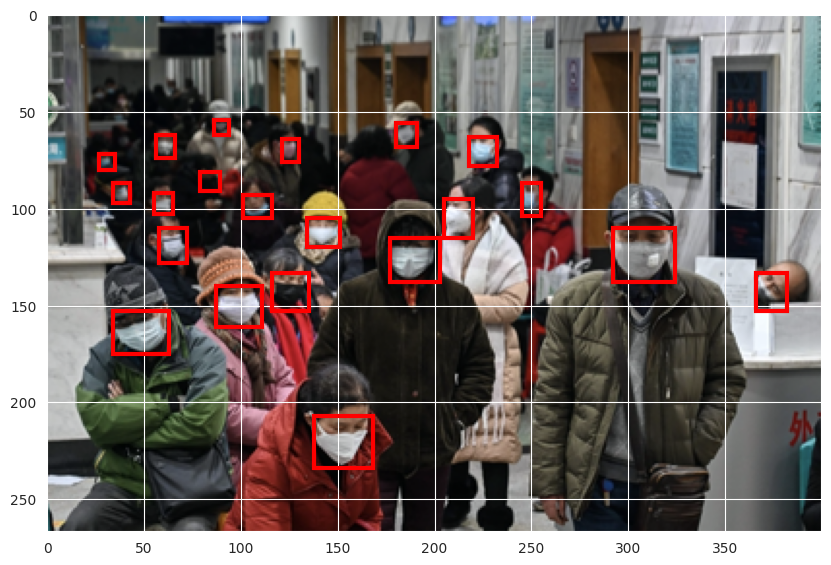

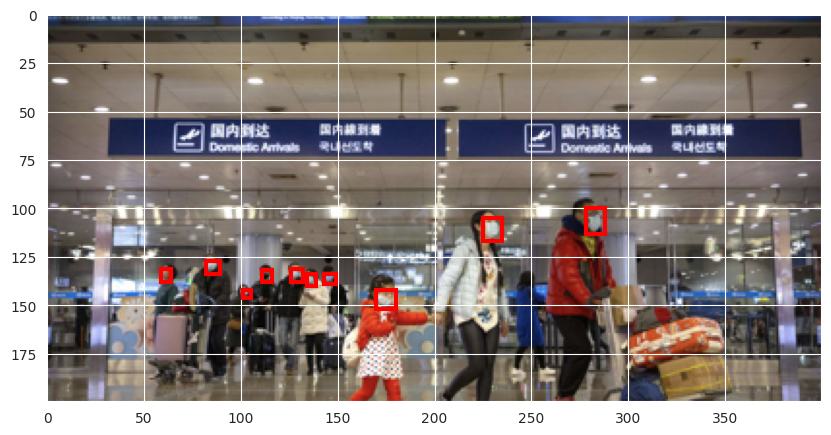

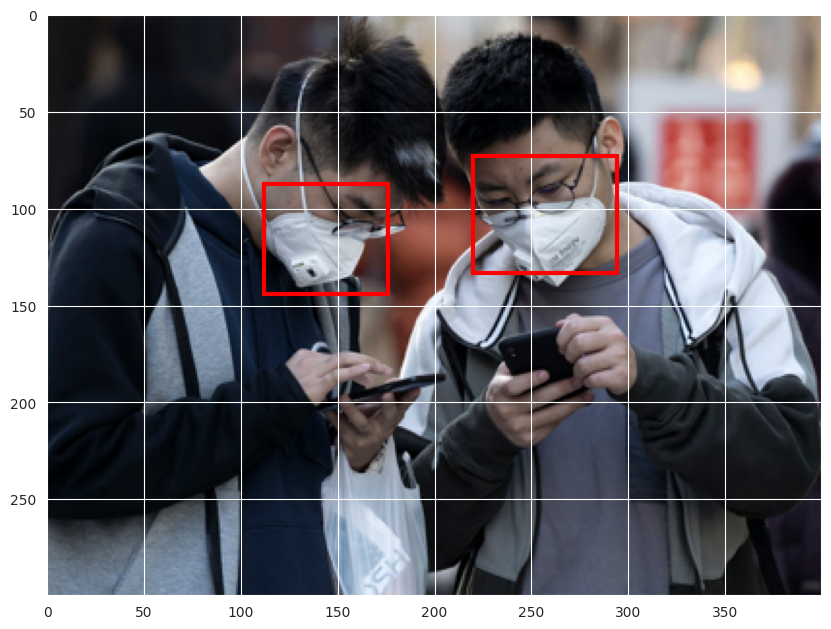

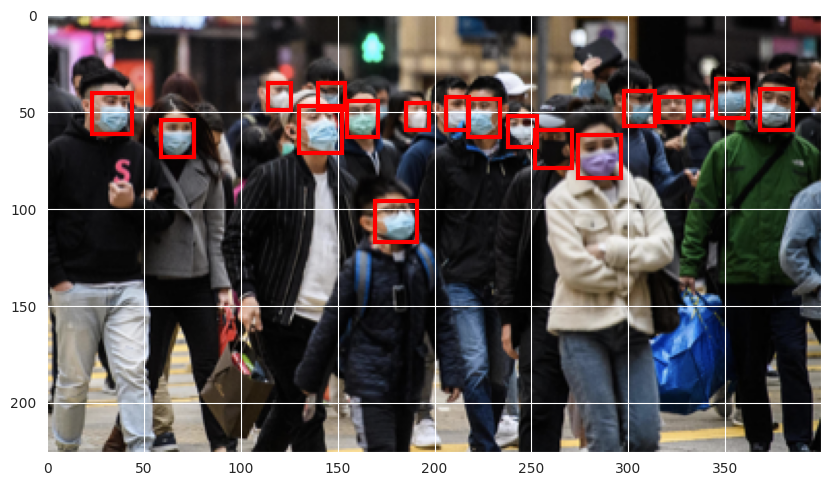

In [ ]:
# Let's look at 5 random images
count = 5
for i in range(count):
    random_image_idx = np.random.choice(df.shape[0])
    image_filename = df.loc[random_image_idx, 'filename']
    plot_bounding_box(IMAGES_PATH, image_filename, df)

In [ ]:
# # 2. YOLO¶
# YOLOv5 is a state-of-the-art object detection model that belongs to the You Only Look Once (YOLO) family. It's known for its speed, accuracy, and ease of use.

# Key Features:
# Real-time performance: YOLOv5 is designed to be fast, making it suitable for real-world applications.
# Accuracy: It achieves high accuracy in object detection tasks.
# Flexibility: It can be used for various object detection tasks, including custom object detection.
# Ease of use: The model is relatively easy to implement and train.
# YOLOv5 processes an entire image at once, dividing it into a grid.
# It then predicts bounding boxes and class probabilities for each grid cell. This approach allows for real-time processing and high speed.

# The model consists of three main components:
# Backbone: Extracts features from the image.
# Neck: Combines features from different layers.
# Head: Predicts bounding boxes and class probabilities.



In [ ]:
# According to the documentation for creating custom models from Ultralitics, in order to feed data into the YOLOv5 model and train it for a custom task, it is necessary to create a directory with images and annotations in a special way.

# To train the model, you need to create a data configuration file in YAML format. It specifies the paths to folders with images and annotations that relate to the training, validation and test (optional) samples, as well as class names.

# For example, let's say we have a root directory for a dataset, let's call it dataset:

In [ ]:
# dataset
#  └─dataset.yaml
#  └─images
#    └─train
#      └─img1.png
#      └─img2.png
#    └─val
#      └─img3.png
#      └─img4.png
#  └─labels
#    └─train
#      └─img1.txt
#      └─img2.txt
#    └─val
#      └─img3.txt
#      └─img4.txt

In [ ]:
DATA_PATH = "/content/drive/MyDrive/archive (22)" # Dataset root folder

LABELS_PATH = os.path.join(DATA_PATH, "labels") # Annotations folder
IMGS_PATH = os.path.join(DATA_PATH, "images") # Images folder

TRAIN_IMAGES_PATH = os.path.join(IMGS_PATH, "train") # Path to the folder with training images
VAL_IMAGES_PATH = os.path.join(IMGS_PATH, "val") # Path to the folder with validation images
TRAIN_LABELS_PATH = os.path.join(LABELS_PATH, "train") # Path to the folder with training annotations
VAL_LABELS_PATH = os.path.join(LABELS_PATH, "val") # Path to the folder with validation annitations

DATA_CONFIG_PATH = os.path.join(DATA_PATH, "dataset.yaml") # Path to data configuration file

print(TRAIN_IMAGES_PATH)
print(VAL_IMAGES_PATH)
print(TRAIN_LABELS_PATH)
print(VAL_LABELS_PATH)
print(DATA_CONFIG_PATH)

/content/drive/MyDrive/archive (22)/images/train
/content/drive/MyDrive/archive (22)/images/val
/content/drive/MyDrive/archive (22)/labels/train
/content/drive/MyDrive/archive (22)/labels/val
/content/drive/MyDrive/archive (22)/dataset.yaml


In [ ]:
# Create a local folder for images and annotations for them (if one does not already exist)
if not os.path.exists(DATA_PATH):
    os.makedirs(DATA_PATH)

# Create a folder for training images (if one does not already exist)
if not os.path.exists(TRAIN_IMAGES_PATH):
    os.makedirs(TRAIN_IMAGES_PATH)

# We create a folder for training annotations for objects (if one does not already exist)
if not os.path.exists(TRAIN_LABELS_PATH):
    os.makedirs(TRAIN_LABELS_PATH)

# We create a folder for validation images (if one does not already exist)
if not os.path.exists(VAL_IMAGES_PATH):
    os.makedirs(VAL_IMAGES_PATH)

# We create a folder for validation annotations for objects (if one does not already exist)
if not os.path.exists(VAL_LABELS_PATH):
    os.makedirs(VAL_LABELS_PATH)

In [ ]:
# Creating the contents of the file
data_config = f'''
path: /content/drive/MyDrive/archive (22)
train: images/train
val: images/val
test:
names:
    0: with_mask
    1: without_mask
    2: mask_weared_incorrect
'''

# We open for writing a file in which write the path configuration and from which the training data will be taken
with open(DATA_CONFIG_PATH, 'w') as f:
    f.write(data_config)

# Checking that everything was recorded correctly
with open(DATA_CONFIG_PATH, 'r') as f:
    print(f.read())


path: /content/drive/MyDrive/archive (22)
train: images/train
val: images/val
test:
names:
    0: with_mask
    1: without_mask
    2: mask_weared_incorrect



In [ ]:

df['class'] = df['name'].map({'with_mask': 0,
                             'without_mask': 1,
                             'mask_weared_incorrect': 2})


df['x_center'] = (df['xmin'] + df['xmax']) / (2 * df['width'])
df['y_center'] = (df['ymin'] + df['ymax']) / (2 * df['height'])

df['box_width'] = (df['xmax'] - df['xmin']).abs() / df['width']
df['box_height'] = (df['ymax'] - df['ymin']).abs() / df['height']


df[['class','x_center','y_center','box_width','box_height']].head()


,class,x_center,y_center,box_width,box_height
0,1,0.478405,0.666250,0.325581,0.357500
1,0,0.386250,0.275000,0.082500,0.110000
2,0,0.707500,0.241667,0.080000,0.090000
3,0,0.830000,0.293333,0.050000,0.080000
4,0,0.915000,0.260000,0.070000,0.106667


In [ ]:
# Creating a general list of file names with images
image_ids = list(set(df['filename']))
# We divide this list into two - training and validation samples
train_ids, val_ids = train_test_split(image_ids, random_state=42, test_size=0.2)
# Looking at sample sizes
print('Train shape: {}'.format(len(train_ids)))
print('Validation shape: {}'.format(len(val_ids)))

Train shape: 520
Validation shape: 130


In [ ]:
#  Create a cycle from images
for filename, mini in tqdm(df.groupby('filename')):
    # If the current file is in the validation set
    if filename in val_ids:
        path2save = 'val'
    # Otherwise (training set)
    else:
        path2save = 'train'
    # We create the path to the file will write the new annotation
    new_annotation_path = os.path.join(LABELS_PATH, path2save, filename[:-4] + ".txt")
    # Open a .txt file for writing
    with open(new_annotation_path, 'w+') as f:
        # Select the coordinates of the bounding rectangle in the format required for YOLOv5
        row = mini[['class','x_center','y_center','box_width','box_height']].astype(float).values
        row = row.astype(str)
        # We record the coordinates of each of the bounding rectangles in the image line by line
        for j in range(len(row)):
            text = ' '.join(row[j])
            f.write(text)
            f.write("\n")
    # Moving images from the original folder to the new folder
    sh.copy(
        os.path.join(IMAGES_PATH, filename),
        os.path.join(IMGS_PATH, path2save, filename)
    )

  0%|          | 0/650 [00:00<?, ?it/s]

1.0 0.18359375 0.337431693989071 0.05859375 0.10109289617486339
0.0 0.4013671875 0.3333333333333333 0.080078125 0.12021857923497267
1.0 0.6689453125 0.3155737704918033 0.068359375 0.13934426229508196
1.0 0.18359375 0.337431693989071 0.05859375 0.10109289617486339
0.0 0.4013671875 0.3333333333333333 0.080078125 0.12021857923497267
1.0 0.6689453125 0.3155737704918033 0.068359375 0.13934426229508196
1.0 0.18359375 0.337431693989071 0.05859375 0.10109289617486339
0.0 0.4013671875 0.3333333333333333 0.080078125 0.12021857923497267
1.0 0.6689453125 0.3155737704918033 0.068359375 0.13934426229508196



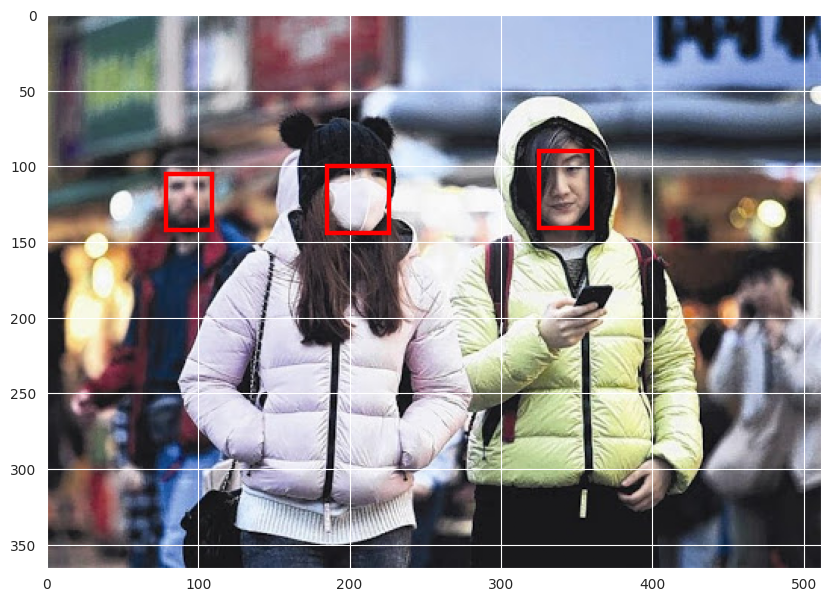

In [ ]:
# Open the annotation file and read the contents
with open(os.path.join(TRAIN_LABELS_PATH, 'maksssksksss0.txt')) as f:
    txt_example = f.read()
# Displaying content on the screen
print(txt_example)
# Let's look at the image
plot_bounding_box(TRAIN_IMAGES_PATH, 'maksssksksss0.png', df)


In [ ]:
# Cloning a repository with the YOLO-v5 model
!git clone https://github.com/ultralytics/yolov5
# Installing the dependencies necessary for the model to work
# !pip install -qr yolov5/requirements.txt

Cloning into 'yolov5'...
remote: Enumerating objects: 16824, done.
remote: Total 16824 (delta 0), reused 0 (delta 0), pack-reused 16824
Receiving objects: 100% (16824/16824), 15.53 MiB | 16.59 MiB/s, done.
Resolving deltas: 100% (11534/11534), done.


In [ ]:
!ls yolov5


benchmarks.py	 data	     LICENSE	     README.zh-CN.md   tutorial.ipynb
CITATION.cff	 detect.py   models	     requirements.txt  utils
classify	 export.py   pyproject.toml  segment	       val.py
CONTRIBUTING.md  hubconf.py  README.md	     train.py


In [ ]:
# Moving to the yolov5 directory
os.chdir('yolov5')
# We import the init_seeds function from there
from utils.general import init_seeds
# We fix the random number generator for reproducibility of results
RANDOM_STATE = 42
init_seeds(RANDOM_STATE)
# Returning to the working directory
os.chdir('../')

In [ ]:
!pip install -q wandb --upgrade

import wandb
wandb.login(anonymous='must')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.6/303.6 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 5.6 MB/s eta 0:00:00


<IPython.core.display.Javascript object>

KeyboardInterrupt: 

In [ ]:
!python yolov5/train.py \
--img 640 \
--batch 10 \
--epochs 50 \
--data {DATA_CONFIG_PATH} \
--weights yolov5s.pt \
--name my_yolov5_model_s

/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `python yolov5/train.py  --img 640  --batch 10  --epochs 50  --data /content/drive/MyDrive/archive (22)/dataset.yaml  --weights yolov5s.pt  --name my_yolov5_model_s'


In [ ]:
# 3. Fast RCNN¶

In [ ]:
data_folder = '/content/drive/MyDrive/archive (22)'

In [ ]:
# This code defines a custom dataset class for loading images with bounding boxes and labels representing mask types.
# It creates a Dataloader for efficient batching during training.
# This code creates a custom dataset class (MaskDataset) to load images with bounding boxes and labels for different mask types (with mask, without mask, worn incorrectly). It uses a Dataloader for efficient batching during training. The dataset reads image filenames, parses corresponding annotations (likely in XML format), and extracts image data, bounding boxes, and labels. The Dataloader groups these elements (image, target) into batches for training your model.
class MaskDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_dir = os.path.join(root_dir, 'images')
        self.annot_dir = os.path.join(root_dir, 'annotations')
        self.transform = transform
        self.image_names = os.listdir(self.image_dir)
        self.image_names.sort()

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, f'maksssksksss{idx}.png')
        image = Image.open(image_path).convert("RGB")

        image = self.transform(image)
        target = {}
        annot_path = os.path.join(self.annot_dir, f'maksssksksss{idx}.xml')
        tree = ET.parse(annot_path)
        root = tree.getroot()
        size = root.find('size')

        boxes = []
        labels = []
        for obj in root.findall('object'):
            label = obj.find('name').text
            if label == 'with_mask':
                labels.append(1)
            elif label == 'without_mask':
                labels.append(2)
            elif label == 'mask_weared_incorrect':
                labels.append(3)
            bndbox = obj.find('bndbox')
            xmin = int(bndbox.find('xmin').text)
            ymin = int(bndbox.find('ymin').text)
            xmax = int(bndbox.find('xmax').text)
            ymax = int(bndbox.find('ymax').text)

            boxes.append([xmin, ymin, xmax, ymax])
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels)
            target['boxes'] = boxes
            target['labels'] = labels
            return image, target

collate_fn = lambda batch: tuple(zip(*batch))


# create dataset and dataloader

# Define transforms for the dataset
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


dataset = MaskDataset(data_folder, transform=train_transforms)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=4, collate_fn=collate_fn)


In [ ]:
# Split data into train sample and test sample
train_data_ratio = 0.8

train_size = int(len(dataset) * train_data_ratio)
test_size = len(dataset) - train_size # test data shouldn't be appeared in training

train_data, test_data = torch.utils.data.random_split(dataset, [train_size, test_size])

print("Train data size: ", len(train_data))
print("Test data size: ", len(test_data))

Train data size:  684
Test data size:  171


In [ ]:
# Loading the Resnet 50 model with pretrained weights
# **RCNN** is a pre-trained model from PyTorch's torchvision library designed for object detection. It utilizes a Faster R-CNN architecture with a ResNet-50 backbone and Feature Pyramid Network (FPN) for efficient and accurate object localization. By loading a pre-trained RCNN, you can leverage knowledge gained from training on large datasets to jumpstart your object detection tasks, saving time and computational resources compared to training a model from scratch.

RCNN = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
RCNN

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:01<00:00, 110MB/s] 


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
# **The code snippet modifies a pre-trained Faster R-CNN model for a custom object detection task.**
# It determines the input feature size of the classification head (`in_features`) from the pre-trained model and replaces it with a new classification head (`FastRCNNPredictor`) tailored to the specific task with `num_classes` output classes. This allows the model to be fine-tuned for the desired number of object categories.
num_classes = 4
in_features = RCNN.roi_heads.box_predictor.cls_score.in_features
RCNN.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

In [ ]:
# Define the optimizer and learning rate scheduler
params = [p for p in RCNN.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(params, lr=1e-4,
                              amsgrad=True,
                              weight_decay=1e-6)
# and a learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                               step_size=5,
                                               gamma=0.5)

# Define the device (GPU or CPU)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')


In [ ]:
def train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq):
    model.train()
    for batch_idx, (images, targets) in enumerate(data_loader):
        # Sending training data to CUDA
        images = list([image.to(device) for image in images])
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        if batch_idx % print_freq == 0:
            print(f'Epoch: {epoch}, Batch: {batch_idx}, Loss: {losses}')

In [ ]:
# Define the number of epochs and batch size
num_epochs = 20
dataloader = DataLoader(train_data, batch_size=4, shuffle=True, num_workers=4, collate_fn=collate_fn)
# Train the model
RCNN.to(torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
for epoch in range(num_epochs):
    train_one_epoch(RCNN, optimizer, dataloader, device, epoch, print_freq=20)
    lr_scheduler.step()


Epoch: 0, Batch: 0, Loss: 4.680008888244629
Epoch: 0, Batch: 20, Loss: 0.15720224380493164
Epoch: 0, Batch: 40, Loss: 0.1606193482875824
